In [1]:
# %pip install -r ../requirements.txt --quiet
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project paths
project_root = os.path.abspath("..")
helpers_path = os.path.join(project_root, "helpers")
models_path = os.path.join(helpers_path, "models")
if helpers_path not in sys.path:
    sys.path.insert(0, helpers_path)

if models_path not in sys.path:
    sys.path.insert(0, models_path)


# Import custom modules
from constants import TARGET_COLUMN, QUICK_TEST
from data_loader import load_station_data
print("Modules imported successfully!")

Modules imported successfully!


In [2]:
# Load all stations' data
station_data = load_station_data()
print(f"Stations available: {list(station_data.keys())}")

# Select a station
SELECTED_STATION = "Station1"  
df = station_data[SELECTED_STATION]

Loaded data from 6 stations.
Stations available: ['Station1', 'Station2', 'Station3', 'Station4', 'Station5', 'Station6']


In [3]:
from feature_engineering import (
    add_time_features, add_fourier_terms, drop_columns, normalize_features
)
# Train-Test Split
train_df = df[df.index.year < 2020]
test_df = df[df.index.year == 2020]


if QUICK_TEST:
    train_df = train_df.iloc[-1000:]  # Last 1000 rows
    test_df = test_df.iloc[-200:]  # Last 200 rows

# Drop irrelevant columns (removes extra `SWC_X`, Latitude, Longitude)
train_df = drop_columns(train_df, TARGET_COLUMN)
test_df = drop_columns(test_df, TARGET_COLUMN)

print(train_df.columns.tolist())

# Apply feature engineering
for func in [add_time_features, add_fourier_terms]:
    train_df = func(train_df)
    test_df = func(test_df)


# Normalize the features
train_df, test_df, scaler = normalize_features(train_df, test_df)

['Ppt', 'SWC_10', 'T_5', 'T_10', 'T_20', 'T_50', 'Tair', 'RH', 'Windspeed', 'Winddirection', 'Srad']


In [5]:
from lstm_helpers import prepare_lstm_data, train_lstm


# Prepare LSTM Data
X_train, y_train, X_test, y_test = prepare_lstm_data(train_df, test_df, TARGET_COLUMN)
lstm_model = train_lstm(X_train, y_train, X_test, y_test)

Epoch 1/10


c:\Users\chris\miniconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 862ms/step - loss: 0.0393 - val_loss: 0.6999 - learning_rate: 0.0010
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: 0.0018 - val_loss: 0.7974 - learning_rate: 0.0010
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: 7.1872e-04 - val_loss: 0.8086 - learning_rate: 0.0010
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - loss: 4.2580e-04 - val_loss: 0.8095 - learning_rate: 0.0010
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: 2.8197e-04 - val_loss: 0.8142 - learning_rate: 0.0010
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 979ms/step - loss: 2.0209e-04 - val_loss: 0.8228 - learning_rate: 0.0010
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 967ms/step - loss: 1.8961e-04 - val_loss: 0.8233 - learning_rate: 5.0000e-04
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 961ms/step - loss: 1.7633e-04 - val_loss: 0.8299 - learning_rate: 5.0000e-04
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 968ms/step - loss: 1.6568e-04 - val_loss: 0.8340 - learning_r

In [10]:
from lstm_helpers import make_lstm_predictions

# Make predictions
lstm_predictions = make_lstm_predictions(lstm_model, test_df, TARGET_COLUMN)

# Create a placeholder DataFrame filled with the mean values of train_df
preds_placeholder = np.tile(train_df.mean().values, (lstm_predictions.shape[0], 1))

# Insert LSTM predictions into the correct target column
preds_placeholder[:, test_df.columns.get_loc(TARGET_COLUMN)] = lstm_predictions.reshape(-1)

# Apply inverse transformation
lstm_predictions_rescaled = scaler.inverse_transform(preds_placeholder)[:, test_df.columns.get_loc(TARGET_COLUMN)]

print("Rescaled Predictions:", lstm_predictions_rescaled[:5])  # Print first 5 predictions


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Rescaled Predictions: [0.11276563 0.1129287  0.11316948 0.11348606 0.1138197 ]


In [11]:
from evaluation_helpers import evaluate_model

# Get the last 24 hours of actual values
y_actual = df[TARGET_COLUMN].values[-24:]

# Ensure predictions are properly reshaped
lstm_predictions = lstm_predictions.reshape(-1)  

# Evaluate LSTM
evaluate_model(y_actual, lstm_predictions, model_name="LSTM")


LSTM Evaluation:
Root Mean Squared Error (RMSE): 0.0030
Mean Absolute Error (MAE): 0.0532


(0.0030055342987228006, 0.053193469793846204)

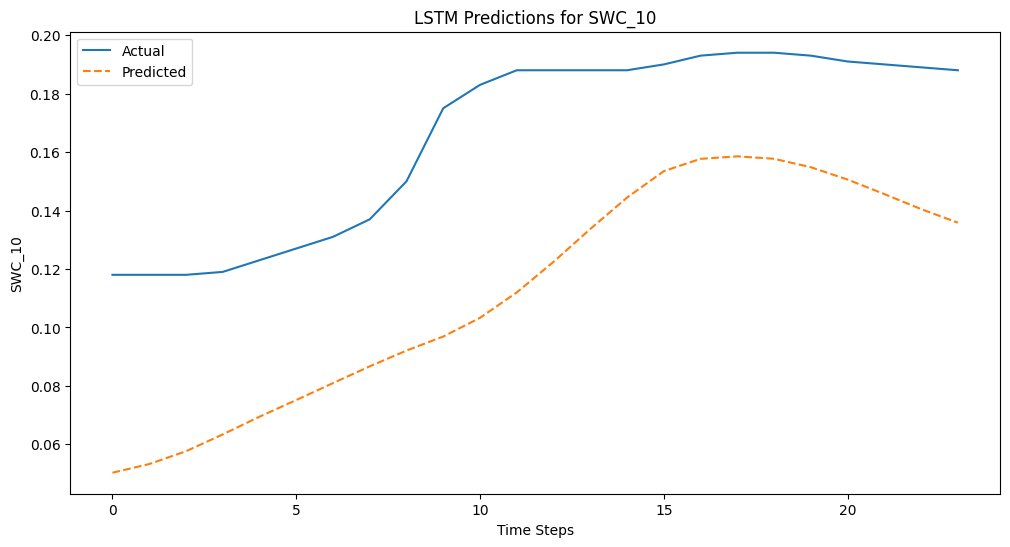

In [8]:
from plotting import plot_lstm_predictions

# Plot LSTM results
plot_lstm_predictions(y_actual, lstm_predictions, TARGET_COLUMN)
